# etth: Diffusion-TS train-only forecasting (seed 0)

Sequence length is fixed to 128. The raw timeline is split before windowing, and the test scaler is fit only on train data. Run cells from top to bottom.

In [1]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT.name != "Diff-ts" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
assert ROOT.name == "Diff-ts", "Open this notebook from inside the Diff-ts repository."

NAME = "etth"
SEED = 0
GPU = 1
SEQ_LEN = 128
PRED_LEN = 64
CONTEXT_LEN = SEQ_LEN - PRED_LEN
TRAIN_RATIO = 0.9
MILESTONE = 10
ENSEMBLE_SIZE = 20

BASE_CONFIG = ROOT / "Config/etth/etth_128.yaml"
SOURCE_DATA = ROOT / "Data/datasets/ETTh.csv"
RESULT_DIR = ROOT / "results" / NAME / f"seed_{SEED}"
SPLIT_DIR = RESULT_DIR / "data"
TRAIN_DATA = SPLIT_DIR / "ETTh_train.csv"
TEST_DATA = SPLIT_DIR / "ETTh_test_with_context.csv"
RUN_CONFIG = RESULT_DIR / "etth_128_train_only.yaml"
CHECKPOINT_BASE = ROOT / "artifacts" / "train-only" / NAME / f"seed_{SEED}" / "checkpoints"
CHECKPOINT_DIR = Path(f"{CHECKPOINT_BASE}_{SEQ_LEN}")

RUN_TRAINING = False # Make this True to run training, False to skip training and load the latest checkpoint from CHECKPOINT_DIR
RUN_SAMPLING = False

print("repository:", ROOT)
print("seed / GPU:", SEED, GPU)
print("checkpoint directory:", CHECKPOINT_DIR)
print("result directory:", RESULT_DIR)

repository: /path/to/Diffusion-TS
seed / GPU: 0 1
checkpoint directory: /path/to/Diffusion-TS/artifacts/train-only/etth/seed_0/checkpoints_128
result directory: /path/to/Diffusion-TS/results/etth/seed_0


## 1. Train on the chronological train split only

The raw ETTh timeline is split before sliding windows are created. The train-only scaler is reused for test data, and forecast targets begin strictly after the train boundary.

In [2]:
def prepare_train_only_config():
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)

    frame = pd.read_csv(SOURCE_DATA)
    split_index = int(len(frame) * TRAIN_RATIO)
    if split_index <= SEQ_LEN or len(frame) - split_index < PRED_LEN:
        raise ValueError("The chronological split is too short for the requested window.")

    train_frame = frame.iloc[:split_index].copy()
    test_frame = frame.iloc[split_index:].copy()
    test_with_context = pd.concat(
        [train_frame.tail(CONTEXT_LEN), test_frame],
        axis=0,
        ignore_index=True,
    )

    train_frame.to_csv(TRAIN_DATA, index=False)
    test_with_context.to_csv(TEST_DATA, index=False)

    with BASE_CONFIG.open() as config_file:
        config = yaml.safe_load(config_file)

    train_params = config["dataloader"]["train_dataset"]["params"]
    train_params["data_root"] = str(TRAIN_DATA)
    train_params["proportion"] = 1.0
    train_params["period"] = "train"
    train_params.pop("scaler_data_root", None)

    config["dataloader"]["test_dataset"]["target"] = "Data.comparison_datasets.TrainScalerCustomDataset"
    test_params = config["dataloader"]["test_dataset"]["params"]
    test_params["data_root"] = str(TEST_DATA)
    test_params["scaler_data_root"] = str(TRAIN_DATA)
    test_params["proportion"] = 0.0
    test_params["period"] = "test"

    with RUN_CONFIG.open("w") as config_file:
        yaml.safe_dump(config, config_file, sort_keys=False)

    first_test_target_source_index = split_index
    last_train_source_index = split_index - 1
    assert first_test_target_source_index > last_train_source_index

    print({
        "raw_rows": len(frame),
        "train_rows": len(train_frame),
        "test_rows": len(test_frame),
        "context_rows_carried_into_test": CONTEXT_LEN,
        "last_train_source_index": last_train_source_index,
        "first_test_target_source_index": first_test_target_source_index,
    })
    return config

run_config = prepare_train_only_config()

def training_command():
    return [
        sys.executable, "-u", "main.py",
        "--name", NAME,
        "--config_file", str(RUN_CONFIG),
        "--gpu", str(GPU),
        "--task", "forecasting",
        "--train",
        "--seed", str(SEED),
        "--save_dir", str(RESULT_DIR),
        "--checkpoint_dir", str(CHECKPOINT_BASE),
    ]

train_cmd = training_command()
print(" ".join(train_cmd))
if RUN_TRAINING:
    subprocess.run(train_cmd, cwd=ROOT, check=True)
    final_checkpoint = CHECKPOINT_DIR / f"checkpoint-{MILESTONE}.pt"
    assert final_checkpoint.exists(), f"Final checkpoint missing: {final_checkpoint}"
    for milestone in range(1, MILESTONE):
        old_checkpoint = CHECKPOINT_DIR / f"checkpoint-{milestone}.pt"
        if old_checkpoint.exists():
            old_checkpoint.unlink()
    print(f"seed {SEED}: retained train-only checkpoint-{MILESTONE}.pt")

{'raw_rows': 17420, 'train_rows': 15678, 'test_rows': 1742, 'context_rows_carried_into_test': 64, 'last_train_source_index': 15677, 'first_test_target_source_index': 15678}
python -u main.py --name etth --config_file /path/to/Diffusion-TS/results/etth/seed_0/etth_128_train_only.yaml --gpu 1 --task forecasting --train --seed 0 --save_dir /path/to/Diffusion-TS/results/etth/seed_0 --checkpoint_dir /path/to/Diffusion-TS/artifacts/train-only/etth/seed_0/checkpoints


## 2. Forecast the held-out test split

Every ensemble member loads the same seed-specific train-only checkpoint. Only the diffusion sampling seed changes between draws.

In [3]:
def sampling_command(draw_seed):
    return [
        sys.executable, "-u", "main.py",
        "--name", NAME,
        "--config_file", str(RUN_CONFIG),
        "--gpu", str(GPU),
        "--sample", "1",
        "--mode", "predict",
        "--pred_len", str(PRED_LEN),
        "--milestone", str(MILESTONE),
        "--seed", str(draw_seed),
        "--save_dir", str(RESULT_DIR),
        "--checkpoint_dir", str(CHECKPOINT_BASE),
    ]

final_checkpoint = CHECKPOINT_DIR / f"checkpoint-{MILESTONE}.pt"
ensemble_path = RESULT_DIR / f"ddpm_predict_{NAME}_{SEQ_LEN}_ensemble.npy"
print("checkpoint:", final_checkpoint)
print("ensemble:", ensemble_path)

if RUN_SAMPLING:
    assert final_checkpoint.exists(), f"Train-only checkpoint missing: {final_checkpoint}"
    draws = []
    for draw in range(ENSEMBLE_SIZE):
        draw_seed = 100000 + SEED * 100 + draw
        sample_cmd = sampling_command(draw_seed)
        print(f"draw {draw + 1}/{ENSEMBLE_SIZE}, seed={draw_seed}")
        subprocess.run(sample_cmd, cwd=ROOT, check=True)
        draw_path = RESULT_DIR / f"ddpm_predict_{NAME}_{SEQ_LEN}.npy"
        draws.append(np.load(draw_path))
    np.save(ensemble_path, np.stack(draws, axis=0))
    print("saved:", ensemble_path)

checkpoint: /path/to/Diffusion-TS/artifacts/train-only/etth/seed_0/checkpoints_128/checkpoint-10.pt
ensemble: /path/to/Diffusion-TS/results/etth/seed_0/ddpm_predict_etth_128_ensemble.npy


## 3. Forecast metrics, predictive interval, and visualization

All arrays, metrics, and figures are written under the dataset/seed result directory.

{
  "seed": 0,
  "training_split": "chronological_train_only",
  "train_ratio": 0.9,
  "forecast_windows": 1679,
  "MAE": 0.08178019765803268,
  "RMSE": 0.11694528898833459,
  "90%_coverage": 0.5572407045009785,
  "mean_interval_width": 0.15720375567779457
}


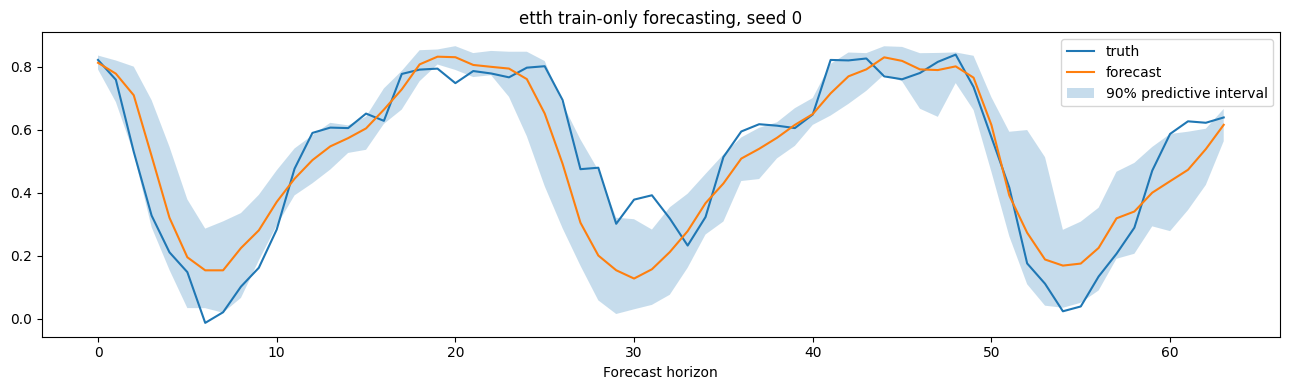

saved: /path/to/Diffusion-TS/results/etth/seed_0/forecast_metrics.json
saved: /path/to/Diffusion-TS/results/etth/seed_0/predictive_interval_etth_128.npz
saved: /path/to/Diffusion-TS/results/etth/seed_0/predictive_interval_etth_128.png


In [4]:
truth_path = RESULT_DIR / "samples" / f"{NAME}_norm_truth_{SEQ_LEN}_test.npy"
assert ensemble_path.exists(), f"Run ensemble sampling first: {ensemble_path}"
assert truth_path.exists(), f"Missing held-out test truth: {truth_path}"

ensemble = np.load(ensemble_path)
truth = np.load(truth_path)
n = min(ensemble.shape[1], len(truth))
ensemble = ensemble[:, :n, -PRED_LEN:, :]
truth = truth[:n, -PRED_LEN:, :]

mean_forecast = ensemble.mean(axis=0)
lower, upper = np.quantile(ensemble, [0.05, 0.95], axis=0)
error = mean_forecast - truth
metrics = {
    "seed": SEED,
    "training_split": "chronological_train_only",
    "train_ratio": TRAIN_RATIO,
    "forecast_windows": int(n),
    "MAE": float(np.mean(np.abs(error))),
    "RMSE": float(np.sqrt(np.mean(error ** 2))),
    "90%_coverage": float(np.mean((truth >= lower) & (truth <= upper))),
    "mean_interval_width": float(np.mean(upper - lower)),
}

metrics_path = RESULT_DIR / "forecast_metrics.json"
interval_path = RESULT_DIR / f"predictive_interval_{NAME}_{SEQ_LEN}.npz"
figure_path = RESULT_DIR / f"predictive_interval_{NAME}_{SEQ_LEN}.png"
metrics_path.write_text(json.dumps(metrics, indent=2) + "\n")
np.savez_compressed(
    interval_path,
    mean=mean_forecast,
    lower=lower,
    upper=upper,
    truth=truth,
)

print(json.dumps(metrics, indent=2))
i, feature = 0, 0
x = np.arange(PRED_LEN)
plt.figure(figsize=(13, 4))
plt.plot(x, truth[i, :, feature], label="truth")
plt.plot(x, mean_forecast[i, :, feature], label="forecast")
plt.fill_between(
    x,
    lower[i, :, feature],
    upper[i, :, feature],
    alpha=0.25,
    label="90% predictive interval",
)
plt.title(f"{NAME} train-only forecasting, seed {SEED}")
plt.xlabel("Forecast horizon")
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", metrics_path)
print("saved:", interval_path)
print("saved:", figure_path)

## Step 2: Extended probabilistic forecasting metrics

This section evaluates the saved 20-member predictive ensemble without retraining or resampling. It separates ensemble-mean point accuracy, expected per-sample error, probabilistic scoring, interval calibration, and ensemble dispersion.


In [5]:
# STEP2_EXTENDED_PROBABILISTIC_METRICS
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

MODEL = 'Diffusion-TS'
TRAINING_SEED = 0
REPOSITORY_ROOT = Path('/path/to/Diffusion-TS')
RESULT_DIRECTORY = REPOSITORY_ROOT / "results" / "etth" / f"seed_{TRAINING_SEED}"
COMMON_EVALUATOR = Path("/path/to/user/DMs/forecasting_eval")
if str(COMMON_EVALUATOR) not in sys.path:
    sys.path.insert(0, str(COMMON_EVALUATOR))

from extended_probabilistic_metrics import evaluate_and_save

extended_metrics, per_draw_metrics = evaluate_and_save(
    model=MODEL,
    training_seed=TRAINING_SEED,
    result_dir=RESULT_DIRECTORY,
    prediction_length=64,
    sequence_length=128,
    train_ratio=0.9,
)

display_metrics = [
    "Ensemble-mean MAE",
    "Ensemble-mean RMSE",
    "Expected sample MAE",
    "Std. sample MAE",
    "Expected sample RMSE",
    "Mean CRPS",
    "90% PICP",
    "90% MPIW",
    "90% normalized MPIW (feature range)",
    "90% interval score",
    "Mean ensemble std",
]
metric_table = pd.DataFrame(
    {"Metric": display_metrics, "Value": [extended_metrics[key] for key in display_metrics]}
)
display(metric_table)
print("saved:", RESULT_DIRECTORY / "forecast_metrics_extended.json")
print("saved:", RESULT_DIRECTORY / "sample_metrics_per_draw.csv")


                                 Metric     Value
0                     Ensemble-mean MAE  0.081780
1                    Ensemble-mean RMSE  0.116945
2                   Expected sample MAE  0.093983
3                       Std. sample MAE  0.000113
4                  Expected sample RMSE  0.133411
5                             Mean CRPS  0.064509
6                              90% PICP  0.557241
7                              90% MPIW  0.157204
8   90% normalized MPIW (feature range)  0.247330
9                    90% interval score  0.735470
10                    Mean ensemble std  0.055120
saved: /path/to/Diffusion-TS/results/etth/seed_0/forecast_metrics_extended.json
saved: /path/to/Diffusion-TS/results/etth/seed_0/sample_metrics_per_draw.csv


## Step 3B: Horizon- and feature-wise probabilistic diagnostics

This standalone cell reads the saved 20-member ensemble and truth arrays; it performs no model sampling or retraining.


In [ ]:
# STEP3B_HORIZON_FEATURE_DIAGNOSTICS
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

MODEL = 'TS'
TRAINING_SEED = 0
REPOSITORY_ROOT = Path('/path/to/Diffusion-TS')
RESULT_DIRECTORY = REPOSITORY_ROOT / "results" / "etth" / "seed_{}".format(TRAINING_SEED)
COMMON_EVALUATOR = Path("/path/to/user/DMs/forecasting_eval")
SOURCE_CSV = (
    REPOSITORY_ROOT
    / "Data"
    / "datasets"
    / "ETTh.csv"
)
if str(COMMON_EVALUATOR) not in sys.path:z
    sys.path.insert(0, str(COMMON_EVALUATOR))

from horizon_feature_diagnostics import evaluate_result_directory

horizon_metrics, feature_metrics, matrix_metrics, validation, metadata = evaluate_result_directory(
    MODEL, TRAINING_SEED, RESULT_DIRECTORY, SOURCE_CSV
)
display(horizon_metrics[["horizon", "Expected sample MAE", "Mean CRPS", "90% PICP", "90% MPIW", "90% interval score", "Mean ensemble std"]].head())
display(feature_metrics[["feature", "Expected sample MAE", "Mean CRPS", "90% PICP", "90% MPIW", "90% interval score", "Mean ensemble std"]])
print("aggregation validation passed for", len(validation), "metrics")
print("saved Step 3B files in:", RESULT_DIRECTORY / "step3")


   horizon  Expected sample MAE  ...  90% interval score  Mean ensemble std
0        1             0.052430  ...            0.462804           0.027779
1        2             0.065768  ...            0.484689           0.040648
2        3             0.076025  ...            0.527908           0.048713
3        4             0.080067  ...            0.563765           0.051025
4        5             0.082080  ...            0.586085           0.051997

[5 rows x 7 columns]
  feature  Expected sample MAE  ...  90% interval score  Mean ensemble std
0    HUFL             0.120394  ...            1.022998           0.066045
1    HULL             0.103979  ...            0.642841           0.071165
2    MUFL             0.127645  ...            1.105884           0.069144
3    MULL             0.096817  ...            0.594957           0.066191
4    LUFL             0.093352  ...            0.720122           0.054328
5    LULL             0.066957  ...            0.534450           0.0388

## Step 3C: Causal ablation summary

This cell reads only the Diffusion-TS job registered for this training seed.


In [7]:
# STEP3C_CAUSAL_ABLATION_SUMMARY
from pathlib import Path
import yaml
import pandas as pd
from IPython.display import display

TRAINING_SEED = 0
TS_ROOT = Path("/path/to/Diffusion-TS")
CAUSAL_ROOT = Path("/path/to/user/DMs/forecasting_eval/step3_causal")
registry = yaml.safe_load((CAUSAL_ROOT / "experiment_registry.yaml").read_text())
jobs = [job for job in registry["jobs"] if job["repository"] == "ts" and job["training_seed"] == TRAINING_SEED]
assert all(Path(job["repository_root"]) == TS_ROOT for job in jobs)
columns = ["variant", "training_seed", "status", "attempts", "status_reason", "run_dir"]
display(pd.DataFrame(jobs).reindex(columns=columns))
print("causal experiment status: INCOMPLETE; no TS metrics are reported until retraining finishes")


   variant  ...                                            run_dir
0  TS_BASE  ...  /path/to/user/DMs/forecasting_eval/step3_causal/...

[1 rows x 6 columns]
causal experiment status: INCOMPLETE; no TS metrics are reported until retraining finishes
